# RAG_LLM with Fusion/Tiling Workload Analysis

Our first experiment evaluates attention softmax fusion. We compare the unfused baseline against a fused variant in which \texttt{QK}, \texttt{QK\_softmax}, and \texttt{AV} share a mapping that keeps attention scores in the register file across softmax, eliminating the writeback the baseline incurs. This targets producer-consumer reuse: \texttt{QK} is consumed exactly once, so materializing it at a higher memory level is pure overhead. We sweep document length $T \in \{128, 512, 2048, 8192\}$ at $N{=}10^5$ on the decoder attention, since $MM = 1024 + K \cdot T$ makes it the dominant workload. We present results as a grouped bar chart of energy-per-level stacked per $T$ value. We expect the DRAM-energy bar to shrink in the fused configuration and the gap to widen with $T$, since \texttt{QQKK} scales as $MM^2$ and spills to DRAM at larger $T$. \\

Edit: The main computation bottleneck for the RAG steps is document similarity computation. I will focus on optimizations to improve this. I'll also try fusing intermediate tensors into a closer memory space.


## Analysis: 
Fusion does not improve the energy nor latency of RAG, let's look at the heavy FaissScoreComputation:

doc_scores = query_embedding * corpus_embeddings
1. Number of operations = 1 * 768 * 2_000_000  = 1_536_000_000 MACs (assuming 2M documents)
2. Reads + Writes = 1 * 768 + 768 * 2_000_000 + 1 * 2_000_000 = 1_538_000_768 bytes (assume each value is a byte)

Computational Intensity = 1_536_000_000 / 1_538_000_768 = 0.998 --> 1 MAC/byte

Now look at TPU v4i, assume 1 MAC/cycle 
1. Peak computation throughput = 1.05e9 * 128 * 128 = 1.72e13 MAC/s
2. Peak memory bandwidth (from Main Memory) = 8 * 614e9 / 8 = 614e9 bytes/s
   Peak memory bandwidth (from Global buffer) = 8 * 2048e9 / 8 = 2048e9 bytes/s

Peak: 1.72e13 MAC/s / (614e9 bytes/s) = 28 MAC/byte > 1 MAC/byte
      1.72e13 MAC/s / (2048e9 bytes/s) = 8.39 MAC/byte > 1 MAC/byte

doc_scores is a therefore a memory-bound computation, even if we put it closer to the PEs (in Global buffer for example) our latency is limited by memory. Fusion/tiling can't help here because we can't get out of reading+writing 1_538_000_768 bytes


For fusion to improve anything: 
Computational Intensity > 8.39

1. Number of operations = B * 768 * 2_000_000  = B * 1_536_000_000 MACs (assuming 2M documents)
2. Reads + Writes = B * 768 + 768 * 2_000_000 + B * 2_000_000 = 1_538_000_768 bytes (assume each value is a byte)

= B * 1_536_000_000 / (2_000_768B + 768 * 2_000_000) > 8, solve B >= 9


# Experiments

## Step 1: Imports

In [2]:
import sys
import os

# Make _load_spec.py and scripts/ importable from the workspace root
WORKSPACE_DIR = os.path.dirname(os.path.abspath('.'))
sys.path.insert(0, '/home/workspace/workspace')
sys.path.insert(0, '/home/workspace/workspace/scripts')

import accelforge as af
from _load_spec import get_spec
from utils import Result, round_rank_sizes
from plots import bar_side_by_side, bar_stacked, plot
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pandas as pd
%matplotlib inline

## Step 2: Define Parameters

Edit these dicts to change the RAG_LLM workload size or the architecture configuration.

In [3]:
# RAG_LLM Jinja parameters (passed to workload/RAG_LLM.yaml)
rag_params = {
    'N_DOCS':     5_000_000,   # number of documents in corpus, EdgeRAG range from 3k to 5M
    'N_TOKENS':   512,    # query token length
    'K':     10,     # top-k documents retrieved
    'L': 512 # length of each document
}

# basic8 Jinja parameters (passed to arch/basic8.yaml)
# arch_overrides = {
#     'DRAM_SIZE_GB':       8,     # off-chip DRAM capacity in GB
#     'DRAM_BW_GBps':       68,    # LPDDR5 bandwidth in GB/s
#     'SRAM_SIZE_MB':       8,     # on-chip SRAM capacity in MB
#     'SRAM_READ_BW_GBps':  512,   # SRAM read bandwidth in GB/s
#     'SRAM_WRITE_BW_GBps': 128,   # SRAM write bandwidth in GB/s
#     'MAC_ENERGY_pJ':      0.084, # FP16 MAC energy in pJ
#     'MAC_CLOCK_GHz':      1,     # clock frequency in GHz
# }

print('RAG_LLM params:', rag_params)
# print('Arch overrides:', arch_overrides)

RAG_LLM params: {'N_DOCS': 5000000, 'N_TOKENS': 512, 'K': 10, 'L': 512}


## Step 3: Load the RAG_LLM Workload

In [4]:
WORKLOAD_PATH = '/home/workspace/workspace/workload/full_EdgeRAG_v3.yaml'

workload = af.Workload.from_yaml(
    WORKLOAD_PATH,
    top_key='workload',
    jinja_parse_data={},
)
renames = af.Renames.from_yaml(
    WORKLOAD_PATH,
    top_key='renames',
    jinja_parse_data={},
)
# per einsum sparisty --> TODO just multiply
# print(f'Loaded {len(workload.einsums)} einsums:')
# for e in workload.einsums:
#     print(f'  {e.name}')

## Step 4: Run Each Einsum Through the Architecture

Copy operations (`is_copy_operation: True`) will have zero compute energy â€” that is expected.

In [5]:
print(workload.rank_sizes)

{'BATCH': 100, 'NUM_DOCS': 2000000, 'TOP_K_DOCS': 10, 'DOC_LEN': 512, 'ENC_SEQ_LEN': 512, 'ENC_NUM_HEADS': 12, 'ENC_HEAD_DIM': 64, 'ENC_HIDDEN': 768, 'ENC_FFN_MID': 3072, 'ENC_EMBED_DIM': 768, 'DEC_SEQ_LEN': 5632, 'DEC_NUM_HEADS': 20, 'DEC_HEAD_DIM': 128, 'DEC_HIDDEN': 2560, 'DEC_FFN_MID': 6912, 'DEC_VOCAB': 32000}


AREA: 0.00025907615999999997
FaissScoreComputation results
0    0.005655
Name: Total<SEP>latency, dtype: float32
____
0    0.215795
Name: Total<SEP>energy, dtype: float32
____


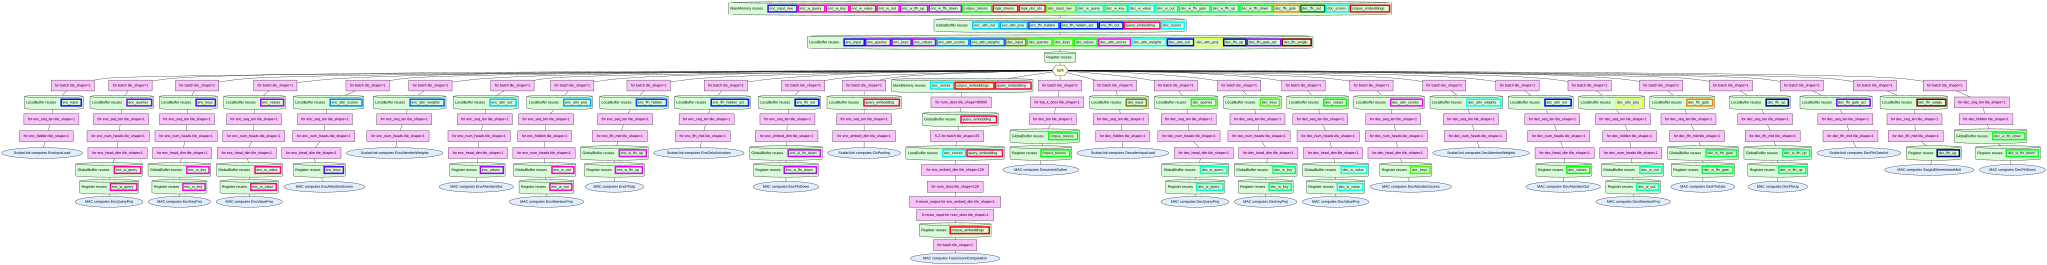

In [13]:
from accelforge.frontend.spec import Spec
from accelforge.mapper import Metrics
from accelforge.mapper.FFM.main import map_workload_to_arch

# spec = Spec.from_yaml(
#     "/home/workspace/workspace/arch/tpu_v4i.yaml",
#     "/home/workspace/workspace/workload/full_EdgeRAG_v3.yaml",
#     jinja_parse_data={},
# )

WORKLOAD_PATH = '/home/workspace/workspace/workload/full_EdgeRAG_v3.yaml'
ARCH_PATH = "/home/workspace/workspace/arch/tpu_v4i.yaml",
MAPPING_PATH = "/home/workspace/workspace/mapping/fusion_v2.yaml" 

spec = af.Spec.from_yaml(
    MAPPING_PATH,
    WORKLOAD_PATH,
    ARCH_PATH,
    jinja_parse_data={},
)

spec.mapper.metrics = Metrics.LATENCY | Metrics.ENERGY

spec.mapper.max_pmapping_templates_per_einsum = 1 # needs to be small for keep kernel alive
spec.mapper._metric_aggregator = "prod"
area = spec.calculate_component_area_energy_latency_leak().arch.total_area
print(f'AREA: {area}')

# mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
mappings = map_workload_to_arch(spec, einsum_names=["FaissScoreComputation"], print_progress=False, print_number_of_pmappings=False) # , einsum_names=["QK"]

print("FaissScoreComputation results")
print(mappings.data["Total<SEP>latency"])
print("____")
print(mappings.data["Total<SEP>energy"])
print("____")

"""
Baseline:

AREA: 0.00025907615999999997
0    0.018483
Name: Total<SEP>latency, dtype: float32
____
0    0.173535
Name: Total<SEP>energy, dtype: float32
____
"""

# batch size = 100, only FAISS
# 0    0.005655
# Name: Total<SEP>latency, dtype: float32
# ____
# 0    0.215795
# Name: Total<SEP>energy, dtype: float32
# ____
# Area:
# 0.00025907615999999997


spec.mapping

In [14]:
print(mappings.resource_usage()["MainMemory"])
print(mappings.resource_usage()["GlobalBuffer"])
print(mappings.resource_usage()["LocalBuffer"])
print(mappings.resource_usage()["Register"])

# 0
# 0.8701171875
# 0.9453125
# 1.0

0
0.00057220458984375
0.9552001953125
1.0


In [15]:
import pandas as pd

# The dataframe from your mapping
df = mappings.data

analysis = []

for e_obj in workload.einsums:
    e_name = e_obj.name if hasattr(e_obj, 'name') else str(e_obj)

    # 1. Total Energy for this Einsum (Sum all energy components)
    energy_cols = [c for c in df.columns if c.startswith(f"{e_name}<SEP>energy")]
    total_energy = df[energy_cols].sum(axis=1).iloc[0]

    # 2. Compute Energy (MACs specifically)
    mac_energy_cols = [c for c in df.columns if f"{e_name}<SEP>energy<SEP>MAC" in c]
    mac_energy = df[mac_energy_cols].sum(axis=1).iloc[0]

    register_cols = [c for c in df.columns if f"{e_name}<SEP>energy<SEP>Register" in c]
    reg_energy = df[register_cols].sum(axis=1).iloc[0]

    scalar_cols = [c for c in df.columns if f"{e_name}<SEP>energy<SEP>ScalarUnit" in c]
    scalar_energy = df[scalar_cols].sum(axis=1).iloc[0]

    main_cols = [c for c in df.columns if f"{e_name}<SEP>energy<SEP>MainMemory" in c]
    main_energy = df[main_cols].sum(axis=1).iloc[0]

    local_cols = [c for c in df.columns if f"{e_name}<SEP>energy<SEP>LocalBuffer" in c]
    local_energy = df[local_cols].sum(axis=1).iloc[0]

    global_cols = [c for c in df.columns if f"{e_name}<SEP>energy<SEP>GlobalBuffer" in c]
    global_energy = df[global_cols].sum(axis=1).iloc[0]


    # 4. Latency (The Max latency across components usually defines the bottleneck)
    lat_cols = [c for c in df.columns if c.startswith(f"{e_name}<SEP>latency")]
    max_latency = df[lat_cols].max(axis=1).iloc[0]

    analysis.append({
        "Layer": e_name,
        "Total Energy": total_energy,
        "Compute Energy": mac_energy,
        # "Register Energy": reg_energy, 0
        # "Scalar Energy": scalar_energy, 0 
        "Main Memory Energy": main_energy,
        "Local Energy": local_energy,
        "Global Energy": global_energy,
        "Max Latency": max_latency
    })

# Display as a clean Table
results_df = pd.DataFrame(analysis)
print(results_df.to_string(index=False))

overall_total_energy = results_df["Total Energy"].sum()
print("\n=== Overall Total Energy ===")
print(overall_total_energy)


                Layer  Total Energy  Compute Energy  Main Memory Energy  Local Energy  Global Energy  Max Latency
         EncInputLoad      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
         EncQueryProj      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
           EncKeyProj      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
         EncValueProj      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
   EncAttentionScores      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
  EncAttentionWeights      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
      EncAttentionOut      0.000000        0.000000            0.000000      0.000000       0.000000          NaN
     EncAttentionProj      0.000000        0.000000            0.000000      0.000000   

Running EncInputLoad...
  done — 121.15 pJ/compute
Latency: 1.2808338397007901e-05s, 3.64660702614687e-14s/compute
	ScalarUnit: 1.860119046639963e-12s/compute
	LocalBuffer: 0.0s/compute
	MainMemory: 3.257328868438991e-12s/compute
Running EncQueryProj...
  done — 0.33 pJ/compute
Latency: 4.3885713239433244e-05s, 3.64660702614687e-14s/compute
	MAC: 1.453218005187471e-14s/compute
	LocalBuffer: 0.0s/compute
	MainMemory: 5.513707607076191e-15s/compute
	Register: 0.0s/compute
Running EncKeyProj...
  done — 0.33 pJ/compute
Latency: 4.3885713239433244e-05s, 3.64660702614687e-14s/compute
	MAC: 1.453218005187471e-14s/compute
	LocalBuffer: 0.0s/compute
	MainMemory: 5.513707607076191e-15s/compute
	Register: 0.0s/compute
Running EncValueProj...
  done — 0.33 pJ/compute
Latency: 4.3885713239433244e-05s, 3.64660702614687e-14s/compute
	MAC: 1.453218005187471e-14s/compute
	LocalBuffer: 0.0s/compute
	MainMemory: 5.513707607076191e-15s/compute
	Register: 0.0s/compute
Running EncAttentionScores...
  done 

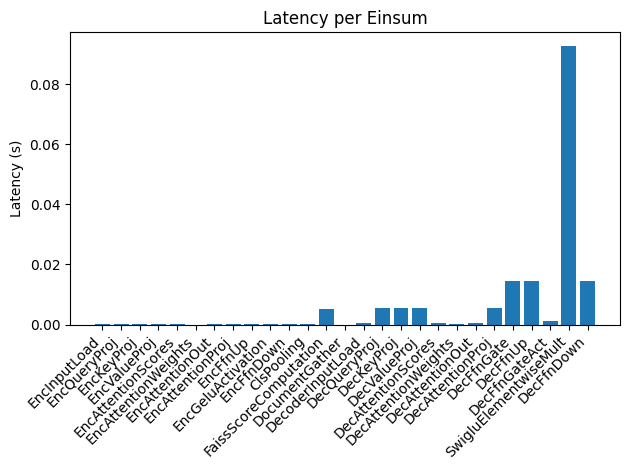

In [8]:
import matplotlib.pyplot as plt

# WHY IS MAIN MEMORY STILL PLAYING A ROLE

results = {}
einsum_names = []
latencies = []
per_compute_latencies = []

mapping_of_interest = None

for einsum in workload.einsums:
    print(f'Running {einsum.name}...')
    # basic8 already includes Disk, MainMemory, OnChipSRAM — no dummy memory needed
    # spec = get_spec('basic8', add_dummy_main_memory=False, jinja_parse_data=arch_overrides)

    spec = Spec.from_yaml("/home/workspace/workspace/arch/tpu_v4i.yaml",
                          "/home/workspace/workspace/mapping/fusion_v2.yaml",
                          jinja_parse_data={})
    spec.renames = renames
    spec.workload = af.Workload(
        einsums=[einsum],
        rank_sizes=workload.rank_sizes,
        bits_per_value=workload.bits_per_value,
        persistent_tensors=workload.persistent_tensors,
    )

    spec.arch.find_spatial("Z").min_usage = 1
    spec.arch.find_spatial("reuse_input").min_usage = 1
    spec.arch.find_spatial("reuse_output").min_usage = 1
    spec.mapper.max_pmapping_templates_per_einsum = 1
    spec.mapper._metric_aggregator = "prod"

    # round_rank_sizes(spec.workload)
    spec.mapper.metrics = af.mapper.Metrics.ENERGY | af.mapper.Metrics.LATENCY

    einsum_mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
    results[einsum.name] = Result(einsum_mappings, variables=rag_params)
    print(f'  done — {results[einsum.name].per_compute("energy")*1e12:.2f} pJ/compute')
    print(f'Latency: {einsum_mappings.latency()}s, {mappings.per_compute().latency()}s/compute')

    for k, v in einsum_mappings.per_compute().latency(per_component=True).items():
        print(f'\t{k}: {v}s/compute')

    # store results
    einsum_names.append(einsum.name)
    latencies.append(einsum_mappings.latency())
    per_compute_latencies.append(einsum_mappings.per_compute().latency())

    # if einsum.name == "DecoderInputLoad": # "only analyze prefill + retrieval
    #     break


print('All einsums complete.')
print("SUM LATENCY")
print(sum(latencies))

plt.figure()
plt.bar(einsum_names, latencies)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Latency (s)")
plt.title("Latency per Einsum")
plt.tight_layout()
plt.show()

In [9]:
mappings # print mappings per einsum, currently only printing the last one
print("pass")

pass


## Step 5: Inspect Results

In [ ]:
print(f'{"Einsum":<30} {"pJ/compute":>12}  Per-component energy (fJ/compute)')
print('-' * 80)
for name, result in results.items():
    result.clear_zero_energies()
    pj = result.per_compute('energy') * 1e12
    components = {k: f'{v*1e15:.2f}fJ' for k, v in result.per_compute('per_component_energy').items()}
    print(f'{name:<30} {pj:>12.2f}  {components}')

In [ ]:
total_pj = 0.0

print(f'{"Einsum":<30} {"pJ/compute":>12}')
print('-' * 50)

for name, result in results.items():
    result.clear_zero_energies()
    pj = result.per_compute('energy') * 1e12
    total_pj += pj
    print(f'{name:<30} {pj:>12.2f}')

print('-' * 50)
print(f'{"TOTAL":<30} {total_pj:>12.2f}')

## Step 6: Plot Per-Einsum Energy Breakdown

In [ ]:
plot_data = {}
for name, result in results.items():
    result.clear_zero_energies()
    plot_data[name] = {k: v * 1e15 for k, v in result.per_compute('per_component_energy').items()}

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Side-by-side bar chart
bar_side_by_side(
    plot_data,
    title='RAG_LLM Per-Einsum Energy Breakdown',
    xlabel='Einsum',
    ylabel='Energy (fJ/compute)',
    ax=axes[0]
)

# Stacked bar chart for better comparison
bar_stacked(
    plot_data,
    title='RAG_LLM Energy Breakdown (Stacked)',
    xlabel='Einsum',
    ylabel='Energy (fJ/compute)',
    ax=axes[1]
)
plt.tight_layout()
plt.show()  # Energy is super high, we are pulling everything from main memory

## Step 7: Analysis Helper Functions

These functions encapsulate the mapping logic so we can run parameter sweeps efficiently.

In [ ]:
def run_rag_workload(rag_params, arch_overrides, einsum_names=None):
    """
    Run the RAG workload with given parameters, returning results for each einsum.

    Parameters
    ----------
    rag_params : dict
        Workload parameters (N_DOCS, N_TOKENS, K, L)
    arch_overrides : dict
        Architecture parameters (DRAM_SIZE_GB, SRAM_SIZE_MB, etc.)
    einsum_names : list, optional
        Which einsums to run. If None, runs all.

    Returns
    -------
    dict[str, Result]
        Results keyed by einsum name
    """
    workload = af.Workload.from_yaml(
        WORKLOAD_PATH,
        top_key='workload',
        jinja_parse_data=rag_params,
    )
    renames = af.Renames.from_yaml(
        WORKLOAD_PATH,
        top_key='renames',
        jinja_parse_data=rag_params,
    )

    results = {}
    for einsum in workload.einsums:
        if einsum_names is not None and einsum.name not in einsum_names:
            continue

        spec = Spec.from_yaml("/home/workspace/workspace/arch/tpu_v4i.yaml", jinja_parse_data={})
        spec.renames = renames
        spec.workload = af.Workload(
            einsums=[einsum],
            rank_sizes=workload.rank_sizes,
            bits_per_value=workload.bits_per_value,
            persistent_tensors=workload.persistent_tensors,
        )

        spec.arch.find_spatial("Z").min_usage = 1
        spec.arch.find_spatial("reuse_input").min_usage = 1
        spec.arch.find_spatial("reuse_output").min_usage = 1
        spec.mapper._metric_aggregator = "prod"
        spec.mapper.max_pmapping_templates_per_einsum = 1
        round_rank_sizes(spec.workload)
        spec.mapper.metrics = af.mapper.Metrics.ENERGY

        mappings = spec.map_workload_to_arch(print_progress=False, print_number_of_pmappings=False)
        results[einsum.name] = Result(mappings, variables=rag_params)

    return results


def aggregate_results(results):
    """
    Aggregate per-einsum results into total energy and per-component breakdown.

    Returns
    -------
    dict with keys:
        'total_energy_J': float
        'total_computes': int
        'per_component_energy_J': dict[str, float]
        'per_einsum_energy_J': dict[str, float]
        'per_einsum_computes': dict[str, int]
    """
    total_energy = 0
    total_computes = 0
    per_component = defaultdict(float)
    per_einsum_energy = {}
    per_einsum_computes = {}

    for name, result in results.items():
        result.clear_zero_energies()
        einsum_energy = sum(result.per_component_energy.values())
        einsum_computes = result.computes

        total_energy += einsum_energy
        total_computes += einsum_computes
        per_einsum_energy[name] = einsum_energy
        per_einsum_computes[name] = einsum_computes

        for comp, energy in result.per_component_energy.items():
            per_component[comp] += energy

    return {
        'total_energy_J': total_energy,
        'total_computes': total_computes,
        'per_component_energy_J': dict(per_component),
        'per_einsum_energy_J': per_einsum_energy,
        'per_einsum_computes': per_einsum_computes,
    }


def get_latency_from_mappings(results):
    """
    Extract latency information from results.
    Note: This requires re-running with LATENCY metric or extracting from mappings.
    For now, we estimate based on bandwidth and data movement.
    """
    # AccelForge Result doesn't directly expose latency in the current wrapper
    # We'll compute estimated latency from energy and bandwidth assumptions
    pass

print("Helper functions defined.")

## Step 8: Initial Bottleneck Analysis

Before sweeping parameters, let's understand what the baseline results tell us about bottlenecks.

In [ ]:
# Analyze bottlenecks from the baseline run
print("=" * 80)
print("BOTTLENECK ANALYSIS: Baseline Configuration")
print(f"N_DOCS={rag_params['N_DOCS']}, N_TOKENS={rag_params['N_TOKENS']}, K={rag_params['K']}")
print("=" * 80)

# Aggregate results
agg = aggregate_results(results)

# 1. Which einsums dominate total energy?
print("\n1. EINSUM ENERGY BREAKDOWN (sorted by energy)")
print("-" * 60)
sorted_einsums = sorted(agg['per_einsum_energy_J'].items(), key=lambda x: x[1], reverse=True)
for name, energy in sorted_einsums:
    pct = 100 * energy / agg['total_energy_J'] if agg['total_energy_J'] > 0 else 0
    print(f"  {name:<12} {energy*1e9:>10.2f} nJ  ({pct:>5.1f}%)")

print(f"\n  TOTAL:      {agg['total_energy_J']*1e9:>10.2f} nJ")

# 2. Which architectural components dominate?
print("\n2. COMPONENT ENERGY BREAKDOWN (sorted by energy)")
print("-" * 60)
sorted_components = sorted(agg['per_component_energy_J'].items(), key=lambda x: x[1], reverse=True)
for comp, energy in sorted_components:
    pct = 100 * energy / agg['total_energy_J'] if agg['total_energy_J'] > 0 else 0
    print(f"  {comp:<15} {energy*1e9:>10.2f} nJ  ({pct:>5.1f}%)")

# 3. Identify the bottleneck
print("\n3. KEY INSIGHTS")
print("-" * 60)
top_einsum = sorted_einsums[0][0] if sorted_einsums else None
top_component = sorted_components[0][0] if sorted_components else None
print(f"  - Highest energy einsum: {top_einsum}")
print(f"  - Highest energy component: {top_component}")

# 4. Per-einsum component breakdown for top consumers
print("\n4. COMPONENT BREAKDOWN FOR TOP ENERGY CONSUMERS")
print("-" * 60)
for name, _ in sorted_einsums[:3]:  # Top 3
    result = results[name]
    result.clear_zero_energies()
    print(f"\n  {name}:")
    for comp, energy in sorted(result.per_component_energy.items(), key=lambda x: x[1], reverse=True):
        total_einsum = sum(result.per_component_energy.values())
        pct = 100 * energy / total_einsum if total_einsum > 0 else 0
        print(f"    {comp:<15} {energy*1e9:>8.2f} nJ  ({pct:>5.1f}%)")

## Step 9: Sweep Number of Documents (N_DOCS)

This experiment varies the RAG corpus size to understand how retrieval scales.

In [ ]:
# Sweep N_DOCS: Number of documents in the RAG corpus
N_DOCS_VALUES = [3600, 7200, 1_000_000, 2_000_000, 5_000_000] # wide range for EdgeRAG

sweep_n_docs_results = {}

print("Sweeping N_DOCS...")
for n_docs in N_DOCS_VALUES:
    print(f"  N_DOCS = {n_docs}...", end=" ")

    params = {
        'N_DOCS': n_docs,
        'N_TOKENS': 512,
        'K': 10,
    }

    results_sweep = run_rag_workload(params, {})
    sweep_n_docs_results[n_docs] = {
        'results': results_sweep,
        'aggregated': aggregate_results(results_sweep),
    }
    print(f"Total energy: {sweep_n_docs_results[n_docs]['aggregated']['total_energy_J']*1e9:.2f} nJ")

print("Done.")

In [ ]:
# Plot N_DOCS sweep results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Total energy vs N_DOCS
ax1 = axes[0, 0]
n_docs_list = list(sweep_n_docs_results.keys())
total_energies = [sweep_n_docs_results[n]['aggregated']['total_energy_J'] * 1e9 for n in n_docs_list]
ax1.plot(n_docs_list, total_energies, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Documents (N_DOCS)')
ax1.set_ylabel('Total Energy (nJ)')
ax1.set_title('Total Energy vs Corpus Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

# 2. Per-component energy vs N_DOCS
ax2 = axes[0, 1]
components = ['MainMemory', 'OnChipSRAM', 'MAC']
for comp in components:
    energies = [sweep_n_docs_results[n]['aggregated']['per_component_energy_J'].get(comp, 0) * 1e9
                for n in n_docs_list]
    ax2.plot(n_docs_list, energies, 'o-', label=comp, linewidth=2, markersize=6)
ax2.set_xlabel('Number of Documents (N_DOCS)')
ax2.set_ylabel('Energy (nJ)')
ax2.set_title('Per-Component Energy vs Corpus Size')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Per-einsum energy for largest N_DOCS
ax3 = axes[1, 0]
largest_n = max(n_docs_list)
einsum_energies = sweep_n_docs_results[largest_n]['aggregated']['per_einsum_energy_J']
sorted_einsums = sorted(einsum_energies.items(), key=lambda x: x[1], reverse=True)
names = [e[0] for e in sorted_einsums]
energies = [e[1] * 1e9 for e in sorted_einsums]
bars = ax3.bar(names, energies)
ax3.set_xlabel('Einsum')
ax3.set_ylabel('Energy (nJ)')
ax3.set_title(f'Per-Einsum Energy (N_DOCS={largest_n})')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# 4. RAG-specific einsums
ax4 = axes[1, 1]
rag_einsums = ['ClsPooling', 'FaissScoreComputation', 'DocumentGather']
for einsum_name in rag_einsums:
    energies = [sweep_n_docs_results[n]['aggregated']['per_einsum_energy_J'].get(einsum_name, 0) * 1e9
                for n in n_docs_list]
    ax4.plot(n_docs_list, energies, 'o-', label=einsum_name, linewidth=2, markersize=6)
ax4.set_xlabel('Number of Documents (N_DOCS)')
ax4.set_ylabel('Energy (nJ)')
ax4.set_title('RAG Retrieval Einsums: Energy Scaling')
ax4.set_xscale('log', base=2)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show() # TODO explore 6.7B, look at graphs dont sum up...

## Step 10: Sweep Document Size (L)

This experiment varies the token length to understand how document size affects energy.
Change in variables: l is size of query, L is length of each document

In [ ]:
L_VALUES = [128, 256, 512, 1024, 2048]

sweep_l_results = {}

print("Sweeping l...")
for l in L_VALUES:
    print(f"  L = {l}...", end=" ")

    params = {
        # 'VOCAB_SIZE': 32000,
        'N_DOCS': 3600,
        'L': l,
        'K': 10,
    }

    results_sweep = run_rag_workload(params, {})
    sweep_l_results[l] = {
        'results': results_sweep,
        'aggregated': aggregate_results(results_sweep),
    }
    print(f"Total energy: {sweep_l_results[l]['aggregated']['total_energy_J']*1e9:.2f} nJ")

print("Done.")

In [ ]:
# Plot L sweep results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

l_list = list(sweep_l_results.keys())

# 1. Total energy vs L
ax1 = axes[0, 0]
total_energies = [sweep_l_results[t]['aggregated']['total_energy_J'] * 1e9 for t in l_list]
ax1.plot(l_list, total_energies, 'o-', linewidth=2, markersize=8, color='green')
ax1.set_xlabel('Token Length (L)')
ax1.set_ylabel('Total Energy (nJ)')
ax1.set_title('Total Energy vs Document Size')
ax1.set_xscale('log', base=2)
ax1.grid(True, alpha=0.3)

# 2. Per-component energy vs L
ax2 = axes[0, 1]
for comp in components:
    energies = [sweep_l_results[t]['aggregated']['per_component_energy_J'].get(comp, 0) * 1e9
                for t in l_list]
    ax2.plot(l_list, energies, 'o-', label=comp, linewidth=2, markersize=6)
ax2.set_xlabel('Token Length (L)')
ax2.set_ylabel('Energy (nJ)')
ax2.set_title('Per-Component Energy vs Document Size')
ax2.set_xscale('log', base=2)
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Attention einsums (Q, K, V, A, H) scaling with L
ax3 = axes[1, 0]
attention_einsums = ['EncInputLoad', 'EncQueryProj', 'EncKeyProj', 'EncValueProj', 'EncAttentionScores', 'EncAttentionWeights', 'EncAttentionOut', 'EncAttentionProj', 'EncFfnUp', 'EncGeluActivation', 'EncFfnDown']
for einsum_name in attention_einsums:
    energies = [sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get(einsum_name, 0) * 1e9
                for t in l_list]
    ax3.plot(l_list, energies, 'o-', label=einsum_name, linewidth=2, markersize=6)
ax3.set_xlabel('Token Length (L)')
ax3.set_ylabel('Energy (nJ)')
ax3.set_title('Attention Einsums: Energy Scaling')
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. RAG vs Attention energy comparison
ax4 = axes[1, 1]
rag_total = [sum(sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get(e, 0)
                 for e in rag_einsums) * 1e9 for t in l_list]
attn_total = [sum(sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get(e, 0)
                  for e in attention_einsums) * 1e9 for t in l_list]
ax4.plot(l_list, rag_total, 'o-', label='RAG (S_score + TK)', linewidth=2, markersize=6)
ax4.plot(l_list, attn_total, 's-', label='Attention (X,Q,K,V,A,H)', linewidth=2, markersize=6)
ax4.set_xlabel('Token Length (L)')
ax4.set_ylabel('Energy (nJ)')
ax4.set_title('RAG vs Attention Energy')
ax4.set_xscale('log', base=2)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 11: 2D Heatmap — N_DOCS × L

Comprehensive analysis of how both parameters interact.

In [ ]:
# 2D sweep: N_DOCS × l
N_DOCS_VALUES = [3600, 7200, 1_000_000, 2_000_000, 5_000_000] # wide range for EdgeRAG
L_VALUES = [128, 256, 512, 1024, 2048]

sweep_2d_results = {}

print("Running 2D sweep (N_DOCS × l)...")
for n_docs in N_DOCS_VALUES:
    for l in L_VALUES:
        print(f"  N_DOCS={n_docs}, L={l}...", end=" ")

        params = {
            # 'VOCAB_SIZE': 32000,
            'N_DOCS': n_docs,
            'L': l,
            'K': 10,
        }

        results_sweep = run_rag_workload(params, {})
        sweep_2d_results[(n_docs, l)] = {
            'results': results_sweep,
            'aggregated': aggregate_results(results_sweep),
        }
        print(f"done")

print("2D sweep complete.")

## Step 12: Prefill vs Decode Stage Analysis

In LLMs, **prefill** processes the full input context (Q, K, V computation), while **decode** generates tokens one at a time. In RAG, we can categorize:

- **Prefill-like**: QKV projections, Attention
- **Retrieval**: Similarity search, document fetch
- **Decode** LLM output generation

In [ ]:
# Categorize einsums into stages
PREFILL_EINSUMS = attention_einsums
RETRIEVAL_EINSUMS = rag_einsums
DECODE_EINSUMS = [
    'DecInputLoad', 'DecQueryProj', 'DecKeyProj', 'DecValueProj',
    'DecAttentionScores', 'DecAttentionWeights', 'DecAttentionOut',
    'DecAttentionProj', 'DecFfnGate', 'DecFfnUp', 'DecFfnGateAct',
    'SwigluElementwiseMult', 'DecFfnDown'
]

def categorize_energy(aggregated):
    """Split energy by stage."""
    prefill = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in PREFILL_EINSUMS)
    retrieval = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in RETRIEVAL_EINSUMS)
    decode = sum(aggregated['per_einsum_energy_J'].get(e, 0) for e in DECODE_EINSUMS)
    return {'Prefill': prefill, 'Retrieval': retrieval, 'Decode': decode}

# Analyze stages across N_DOCS sweep
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Absolute energy by stage
ax1 = axes[0]
prefill_energies = []
retrieval_energies = []
decode_energies = []

for n_docs in N_DOCS_VALUES:
    cat = categorize_energy(sweep_n_docs_results[n_docs]['aggregated'])
    prefill_energies.append(cat['Prefill'] * 1e9)
    retrieval_energies.append(cat['Retrieval'] * 1e9)
    decode_energies.append(cat['Decode'] * 1e9)

x = np.arange(len(N_DOCS_VALUES))
width = 0.25

ax1.bar(x - width, prefill_energies, width, label='Prefill')
ax1.bar(x, retrieval_energies, width, label='Retrieval')
ax1.bar(x + width, decode_energies, width, label='Decode')

ax1.set_xlabel('N_DOCS')
ax1.set_ylabel('Energy (nJ)')
ax1.set_title('Energy by Stage (Prefill vs Retrieval vs Decode)')
ax1.set_xticks(x)
ax1.set_xticklabels(N_DOCS_VALUES)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Percentage breakdown
ax2 = axes[1]
prefill_pct = []
retrieval_pct = []
decode_pct = []

for n_docs in N_DOCS_VALUES:
    cat = categorize_energy(sweep_n_docs_results[n_docs]['aggregated'])
    total = cat['Prefill'] + cat['Retrieval'] + cat['Decode']

    prefill_pct.append(100 * cat['Prefill'] / total if total > 0 else 0)
    retrieval_pct.append(100 * cat['Retrieval'] / total if total > 0 else 0)
    decode_pct.append(100 * cat['Decode'] / total if total > 0 else 0)

ax2.bar(x, prefill_pct, width, label='Prefill')
ax2.bar(x, retrieval_pct, width, bottom=prefill_pct, label='Retrieval')
ax2.bar(x, decode_pct, width,
        bottom=np.array(prefill_pct) + np.array(retrieval_pct),
        label='Decode')

ax2.set_xlabel('N_DOCS')
ax2.set_ylabel('Energy (%)')
ax2.set_title('Energy Distribution by Stage')
ax2.set_xticks(x)
ax2.set_xticklabels(N_DOCS_VALUES)
ax2.legend()
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nStage Energy Summary:")
print("-" * 80)
print(f"{'N_DOCS':<10} {'Prefill (nJ)':<15} {'Retrieval (nJ)':<15} {'Decode (nJ)':<15} {'Retrieval %':<12} {'Decode %':<10}")
print("-" * 80)

for i, n_docs in enumerate(N_DOCS_VALUES):
    print(f"{n_docs:<10} "
          f"{prefill_energies[i]:<15.2f} "
          f"{retrieval_energies[i]:<15.2f} "
          f"{decode_energies[i]:<15.2f} "
          f"{retrieval_pct[i]:<12.1f} "
          f"{decode_pct[i]:<10.1f}")

## Step 13: Summary Report — Bottleneck Analysis

In [ ]:
print("=" * 80)
print("MILESTONE 2 SUMMARY: RAG Bottleneck Analysis")
print("=" * 80)

print("""
ARCHITECTURE: TPUv4i

WORKLOAD: RAG_LLM
  - Embed tokens → QKV → Attention → Similarity → Top-K → Generation
""")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Use baseline results for analysis
agg = aggregate_results(results)
sorted_einsums = sorted(agg['per_einsum_energy_J'].items(), key=lambda x: x[1], reverse=True)
sorted_components = sorted(agg['per_component_energy_J'].items(), key=lambda x: x[1], reverse=True)

print(f"""
1. ARCHITECTURAL BOTTLENECK: {sorted_components[0][0]}
   - Accounts for {100*sorted_components[0][1]/agg['total_energy_J']:.1f}% of total energy

2. EINSUM BOTTLENECK: {sorted_einsums[0][0]}
   - Accounts for {100*sorted_einsums[0][1]/agg['total_energy_J']:.1f}% of total energy
""")

# Analyze bottleneck shifts from ACTUAL sweep data
print("=" * 80)
print("BOTTLENECK SHIFTS (derived from sweep data)")
print("=" * 80)


print("\n3. N_DOCS SWEEP ANALYSIS:")
print("-" * 60)
for n_docs in N_DOCS_VALUES:
    agg_n = sweep_n_docs_results[n_docs]['aggregated']

    # Top einsum
    top_einsum = max(agg_n['per_einsum_energy_J'].items(), key=lambda x: x[1])
    top_einsum_pct = 100 * top_einsum[1] / agg_n['total_energy_J']

    # Top component
    top_comp = max(agg_n['per_component_energy_J'].items(), key=lambda x: x[1])
    top_comp_pct = 100 * top_comp[1] / agg_n['total_energy_J']

    # Retrieval vs Prefill
    retrieval_e = sum(agg_n['per_einsum_energy_J'].get(e, 0) for e in rag_einsums)
    prefill_e = sum(agg_n['per_einsum_energy_J'].get(e, 0) for e in attention_einsums)
    retrieval_pct = 100 * retrieval_e / agg_n['total_energy_J']

    print(f"  N_DOCS={n_docs:>4}: Top einsum={top_einsum[0]:<8} ({top_einsum_pct:>5.1f}%), "
          f"Top component={top_comp[0]:<12} ({top_comp_pct:>5.1f}%), Retrieval={retrieval_pct:>5.1f}%")

print("\n4. L SWEEP ANALYSIS:")
print("-" * 60)
for l in L_VALUES:
    agg_t = sweep_l_results[l]['aggregated']

    # Top einsum
    top_einsum = max(agg_t['per_einsum_energy_J'].items(), key=lambda x: x[1])
    top_einsum_pct = 100 * top_einsum[1] / agg_t['total_energy_J']

    # A (attention) energy
    a_energy = agg_t['per_einsum_energy_J'].get('DecAttentionOut', 0) * 1e9

    print(f"  l={l:>4}: Top einsum={top_einsum[0]:<8} ({top_einsum_pct:>5.1f}%), "
          f"A energy={a_energy:>10.2f} nJ")

# Check quadratic scaling of A
print("\n5. ATTENTION (DecAttentionOut) SCALING CHECK:")
print("-" * 60)
a_energies = [sweep_l_results[t]['aggregated']['per_einsum_energy_J'].get('DecAttentionOut', 0) for t in L_VALUES]
for i in range(1, len(L_VALUES)):
    t_ratio = L_VALUES[i] / L_VALUES[i-1]
    e_ratio = a_energies[i] / a_energies[i-1] if a_energies[i-1] > 0 else 0
    expected = t_ratio ** 2  # quadratic scaling
    print(f"  T: {L_VALUES[i-1]} → {L_VALUES[i]} (×{t_ratio:.1f}): "
          f"A energy ratio = {e_ratio:.2f}× (expected ×{expected:.1f} if quadratic)")

# Create a final summary DataFrame
print("\n" + "=" * 80)
print("DETAILED BREAKDOWN TABLE")
print("=" * 80)

summary_data = []
for name, energy in sorted_einsums:
    computes = agg['per_einsum_computes'][name]
    pj_per_compute = (energy / computes * 1e12) if computes > 0 else 0
    result = results[name]
    result.clear_zero_energies()
    top_component = max(result.per_component_energy.items(), key=lambda x: x[1])[0] if result.per_component_energy else 'N/A'
    summary_data.append({
        'Einsum': name,
        'Energy (nJ)': energy * 1e9,
        '% of Total': 100 * energy / agg['total_energy_J'],
        'Computes': computes,
        'pJ/compute': pj_per_compute,
        'Top Component': top_component,
    })

df = pd.DataFrame(summary_data)
print(df.to_string(index=False))